# 3D Nuclei segmentation pepline


### 1. Install napari & examine original segmentation pepline

In [3]:
#libraries
import numpy as np
from matplotlib import pyplot as plt
from scipy import ndimage as ndi
import skimage as ski
import napari
from skimage.color import label2rgb

In [4]:
# open image
im = ski.io.imread("../Data/Sample3Dimages/DapiB-embryo.tif")

In [5]:
# inspect the image
print("shape: {}".format(im.shape))
print("dtype: {}".format(im.dtype))
print("range: ({}, {})".format(np.min(im), np.max(im))) #range of pixel values 
print(im)

shape: (78, 512, 512)
dtype: uint8
range: (0, 255)
[[[ 1  1  1 ...  3  1  2]
  [ 1  1  1 ...  1  1  1]
  [ 1  1  1 ...  7  1  1]
  ...
  [ 1  1  1 ...  1  1  1]
  [ 1  5  1 ...  1  1  1]
  [ 1  1  1 ...  1  1  1]]

 [[ 1  1  1 ...  1  2  1]
  [ 1  4  2 ...  1  1  1]
  [ 1  4  1 ...  2  3  1]
  ...
  [ 1  1  1 ...  1  1  1]
  [ 1  1  1 ...  1  9  2]
  [ 2  1  2 ...  1  3  1]]

 [[ 1  1  1 ...  1  1  1]
  [ 1  1  1 ...  1  1  1]
  [ 1  1  1 ...  1  2  1]
  ...
  [ 4  1  1 ... 12  1  1]
  [ 1  1  1 ...  8  1  1]
  [ 1  1  1 ...  1 13  1]]

 ...

 [[ 1  1  3 ...  1 11  2]
  [ 1  1  1 ...  1  1  1]
  [ 1  3  1 ...  1  1  1]
  ...
  [ 1  1  1 ...  2  1  1]
  [ 1  1  1 ...  1  1  1]
  [ 1  1  1 ...  1  8  1]]

 [[ 1  1  1 ...  6  1  1]
  [ 1  1  1 ...  1  1  1]
  [ 1  1  1 ...  1  1  1]
  ...
  [ 2  1  1 ...  1  1  2]
  [ 1  1 10 ...  1  1  1]
  [ 1  1  1 ...  1  1  2]]

 [[ 1  1  1 ...  1  1  1]
  [ 1  1  1 ...  1  1  1]
  [ 1  1  1 ...  1  6  1]
  ...
  [ 1  1  1 ...  1  1  1]
  [ 1  1  1 .

In [6]:
np.unique(im) #show the unique pixel values in the image

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [7]:
# set original spacing from metadata with FIJI (Z, Y, X)
spacing = np.array([1, 0.3946, 0.3946]) #in µm
sigma_physical = 1 #in µm
sigma_voxel = sigma_physical / spacing
print("Sigma voxels:", sigma_voxel)

Sigma voxels: [1.         2.53421186 2.53421186]


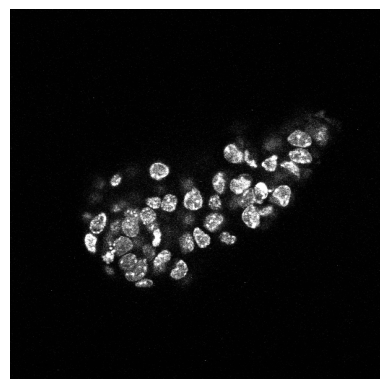

In [8]:
#open napari 
viewer = napari.Viewer(ndisplay=3)
#open images
viewer.add_image(im, name=" DAPI", scale = spacing)
#show one image slice
plt.imshow(im[46],cmap="gray")
plt.axis("off")
plt.show()

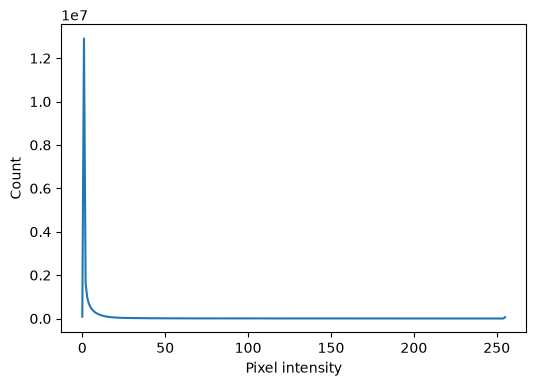

In [9]:
# histogram
hist, hist_centers = ski.exposure.histogram(im)

# Plot histogram
plt.figure(figsize=(6,4))
plt.plot(hist_centers, hist)
plt.xlabel("Pixel intensity")
plt.ylabel("Count")
plt.show()

In [10]:
# visualize only one slice of 3D image in napari
viewer.add_image(im[46], name="slice 46", scale = spacing[1:])

<Image layer 'slice 46' at 0x1511a7610>

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

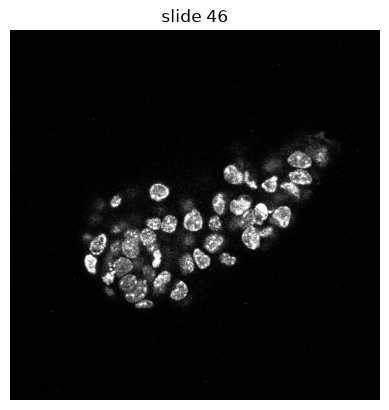

In [11]:
# Plot
plt.title("slide 46")
plt.imshow(im[46], cmap='gray')
plt.axis('off')

In [12]:
#smooth
smooth = ndi.gaussian_filter(im, sigma=sigma_voxel) 
#sigma is the standard deviation of the Gaussian kernel, which controls the amount of smoothing applied to the image.
#A larger sigma will result in more smoothing, while a smaller sigma will preserve more details in the image.

#Compute global threhold with Otsu method
thresh = ski.filters.threshold_otsu(smooth)  
print("the threshold value:",thresh)

binary_nuclei = smooth > thresh #create binary image
#If a pixel value is greater than the threshold → it becomes True (white)

the threshold value: 60


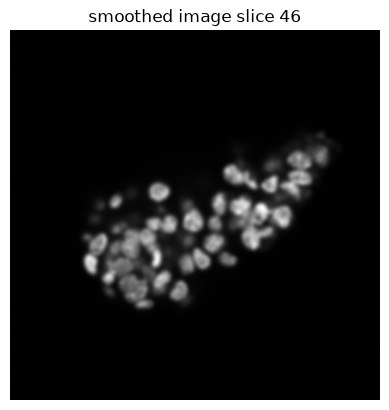

<Image layer 'smoothed image' at 0x153895fd0>

In [13]:
plt.imshow(smooth[46], cmap='gray')
plt.axis('off')
plt.title("smoothed image slice 46")
plt.show()

#view smoothed image with napari
viewer.add_image(smooth, name="smoothed image", scale=spacing)

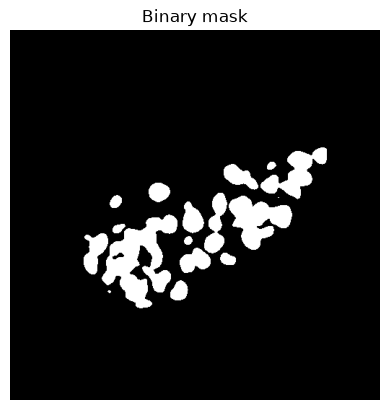

<Image layer 'binary mask' at 0x151251dd0>

In [14]:
plt.imshow(binary_nuclei[46], cmap='gray')
plt.axis('off')
plt.title("Binary mask")
plt.show()

#view bianary mask with napari
viewer.add_image(binary_nuclei, name="binary mask", scale=spacing)

/var/folders/k5/q1x8ytkx367ds0kgvz960wz00000gn/T/ipykernel_60130/76503176.py:2: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_nuclei = ski.morphology.remove_small_objects(binary_nuclei, min_size=100)


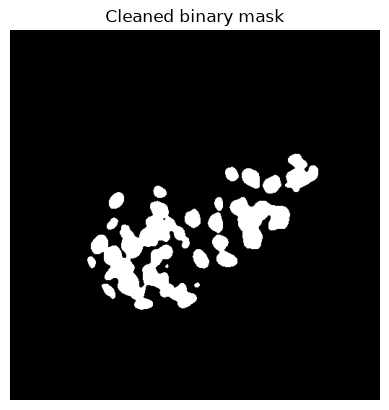

In [15]:
# Remove small objects smaller than 100 pixels
cleaned_nuclei = ski.morphology.remove_small_objects(binary_nuclei, min_size=100)

plt.imshow((cleaned_nuclei[50]),cmap='gray')
plt.title("Cleaned binary mask")
plt.axis(False)
plt.show()

In [16]:
print(np.unique(cleaned_nuclei))
print(np.unique(cleaned_nuclei.astype(np.uint8)))
print(cleaned_nuclei.dtype)

[False  True]
[0 1]
bool


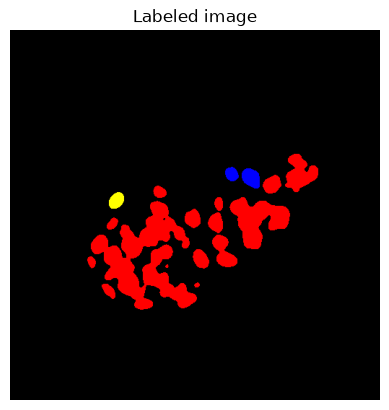

<Labels layer 'Labeled image' at 0x1511a6990>

In [17]:
# Label the binary mask
labels = ski.measure.label(cleaned_nuclei, connectivity=3) 
#Two pixels are connected when they are neighbors and have the same value
#Each connected component (object) in the binary mask is assigned a unique integer label in the output array.

plt.imshow(label2rgb(labels[50]))
#Return an RGB image where each labeled region is colored with a different color.

plt.axis(False)
plt.title("Labeled image")
plt.show()

viewer.add_labels(labels, name="Labeled image", scale=spacing)

In [18]:
np.unique(labels) #Return the sorted unique elements of an array.
#The number of unique labels corresponds to the number of segmented objects in the image.


array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)

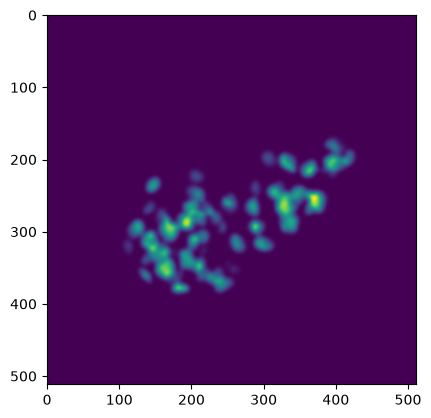

<Image layer 'Distance' at 0x15382dc90>

In [19]:
#distance transform
distance = ndi.distance_transform_edt(cleaned_nuclei) #add sampling=spacing to get distance in physical unit
#The distance transform computes the distance from each pixel to the nearest background pixel (False in the binary mask).
distance = ndi.gaussian_filter(distance, sigma=sigma_voxel) 
#Distance map should be smoothed before peak detection to prevents over-segmentation i()

plt.imshow(distance[50])
plt.show()

viewer.add_image(distance, name="Distance")


In [20]:
#find seed
local_maxi = ski.morphology.local_maxima(distance)  #the maxima is center of the nuclei- TRUE value
print(local_maxi)

#markers
markers= ndi.label(local_maxi) [0] #converts peaks into labeled markers, used as "seeds" for watershed
print(markers.max()) #number of markers

viewer.add_labels(markers, name="markers", scale=spacing)


[[[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 ...

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False Fal

<Labels layer 'markers' at 0x1553daa50>

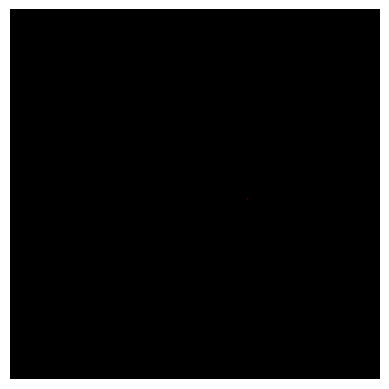

<Labels layer 'watershed' at 0x31ed66b90>

In [21]:
#apply watershed
labels = ski.segmentation.watershed(-distance,markers= markers, mask=cleaned_nuclei) #water goes from low -> high region

plt.imshow(label2rgb(markers[50])) 
plt.axis("off")
plt.show()

viewer.add_labels(labels, name="watershed", scale=spacing)


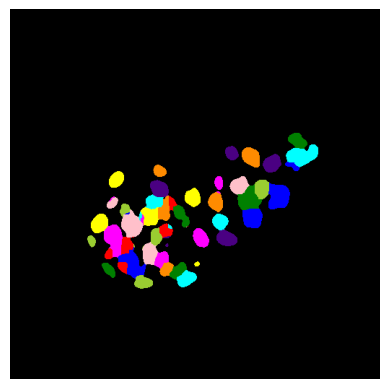

Number of nuclei: 154


<Labels layer 'Nuclei segmentation' at 0x155654250>

In [22]:
plt.imshow(label2rgb(labels[50]))
plt.axis(False)
plt.show()
print("Number of nuclei:", labels.max())

viewer.add_labels(labels, name="Nuclei segmentation", scale=spacing)


## 2. Fully adjusted pepline

In [23]:
#libraries
import numpy as np
from matplotlib import pyplot as plt
from scipy import ndimage as ndi
import skimage as ski
import napari
from skimage.color import label2rgb
from skimage.feature import peak_local_max
from napari_orthogonal_views.ortho_view_manager import show_orthogonal_views
from copy import deepcopy

the threshold value: 60


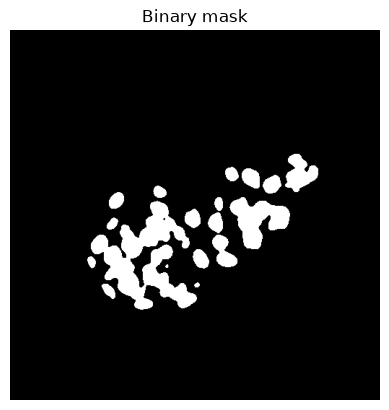

/var/folders/k5/q1x8ytkx367ds0kgvz960wz00000gn/T/ipykernel_60130/51477315.py:24: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_nuclei = ski.morphology.remove_small_objects(binary_nuclei, min_size=150)


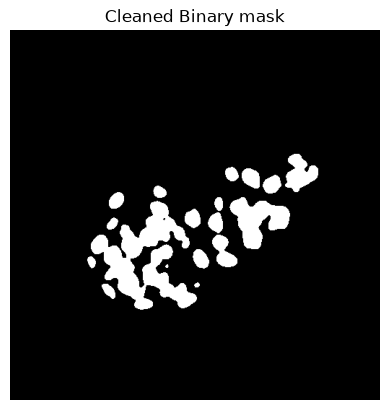

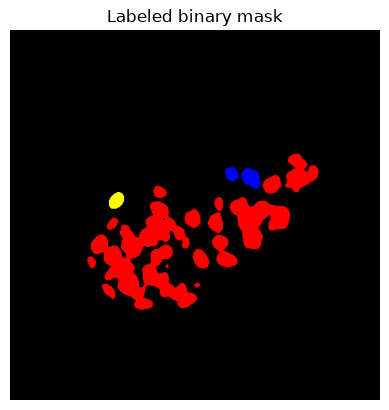

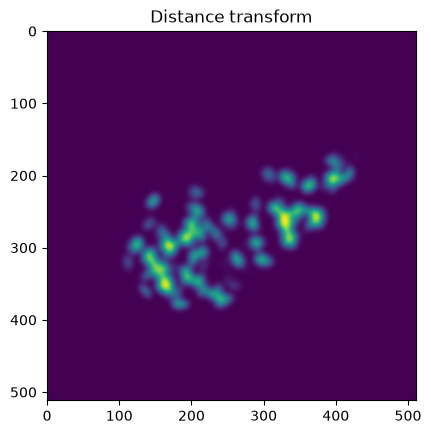

[[[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 ...

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False Fal

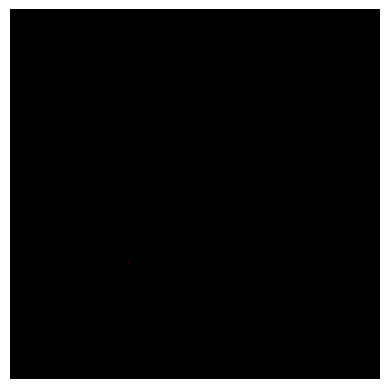

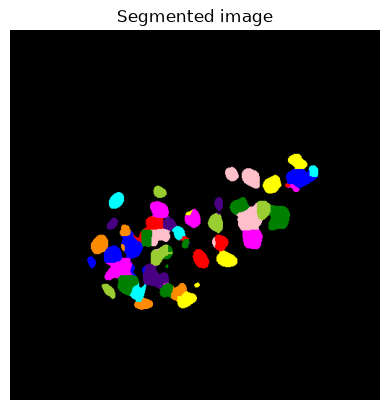

Number of nuclei: 148


<Labels layer 'Watershed segmentation' at 0x3562d88d0>

In [24]:
#full code
im = ski.io.imread ("../Data/Sample3Dimages/DapiB-embryo.tif")

spacing = np.array([1, 0.3946, 0.3946]) #Z, Y, X in µm 

viewer = napari.Viewer(ndisplay=3)

viewer.add_image(im, name=" DAPI", scale = spacing)
      
smooth = ndi.gaussian_filter(im, sigma= 1/spacing) #sigma in physical unit, convert to voxel unit by dividing with spacing

thresh = ski.filters.threshold_otsu(smooth)
print("the threshold value:",thresh)

binary_nuclei = smooth > thresh

plt.imshow(binary_nuclei[50], cmap='gray')
plt.axis('off')
plt.title("Binary mask")
plt.show()   
viewer.add_image(binary_nuclei, name="binary mask", scale=spacing)

# Remove small objects smaller than 150 pixels
cleaned_nuclei = ski.morphology.remove_small_objects(binary_nuclei, min_size=150)
plt.imshow((cleaned_nuclei[50]),cmap='gray')
plt.title("Cleaned Binary mask")
plt.axis(False)
plt.show()

# Label the binary mask
labels_first = ski.measure.label(cleaned_nuclei, connectivity=2)
plt.imshow(label2rgb(labels_first[50]))
np.unique(labels_first) #Return the sorted unique elements of an array.


plt.axis(False)
plt.title("Labeled binary mask")
plt.show()
viewer.add_labels(labels_first, name="Labeled binary mask", scale=spacing)

#distance transform
distance = ndi.distance_transform_edt(cleaned_nuclei, sampling=spacing) #The distance transform computes the distance from each pixel to the nearest background pixel (False in the binary mask).
distance = ndi.gaussian_filter(distance, sigma= 1.5/spacing) #sigma in physical unit, convert to voxel unit by dividing with spacing

plt.imshow(distance[50])
plt.title("Distance transform")
plt.show()
viewer.add_image(distance, name="Distance transform", scale=spacing)

local_maxi = ski.morphology.local_maxima(distance)
print(local_maxi)

markers= ndi.label(local_maxi) [0] # [0] = labeled marker image
print(markers)

#apply watershed
labels_second = ski.segmentation.watershed(-distance,markers= markers, mask=cleaned_nuclei)
plt.imshow(label2rgb(markers[50])) 
plt.axis("off")
plt.show()
viewer.add_labels(markers, name="Markers detection", scale=spacing)   

plt.imshow(label2rgb(labels_second[50]))
plt.title("Segmented image")
plt.axis(False)
plt.show()

print("Number of nuclei:", labels_second.max())
props = ski.measure.regionprops(labels_second) 
props #properties of each segmented object, such as area, perimeter, centroid, etc.

viewer.add_labels(labels_second, name="Watershed segmentation", scale=spacing)        


In [25]:
# Show orthogonal views in napari
show_orthogonal_views(viewer)

## 3. Compare with manual labeling & calculate F1 SCORE

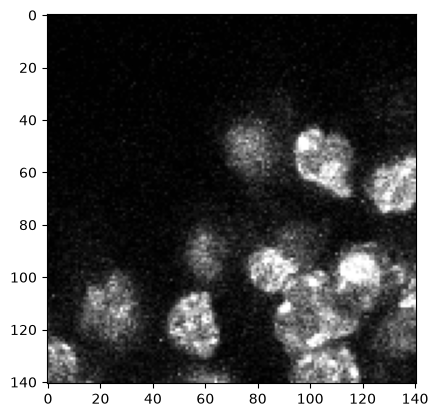

Threshold_cropped : 72


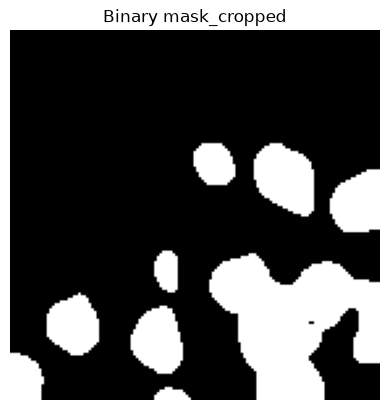

/var/folders/k5/q1x8ytkx367ds0kgvz960wz00000gn/T/ipykernel_60130/4043393336.py:27: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_nuclei_cropped = ski.morphology.remove_small_objects(binary_cropped, min_size=150)


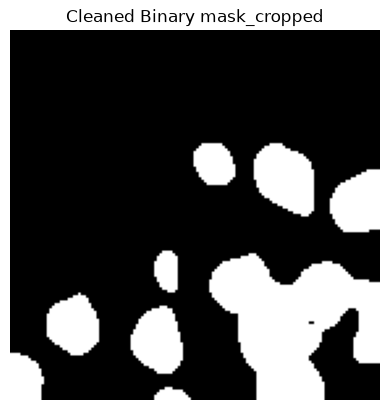

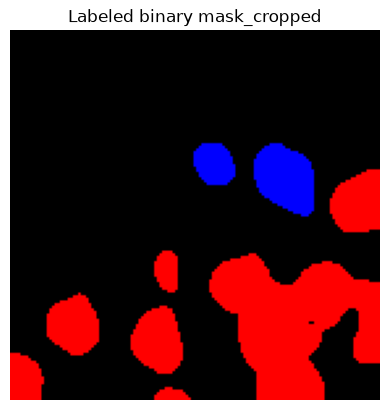

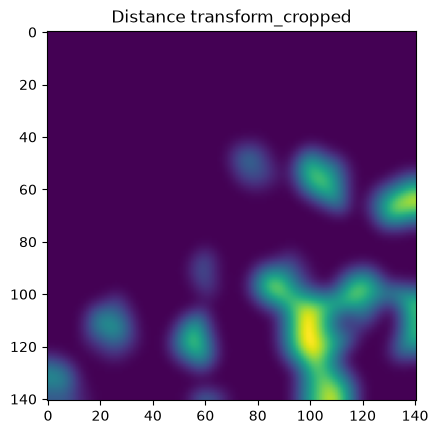

[[[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 ...

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False Fal

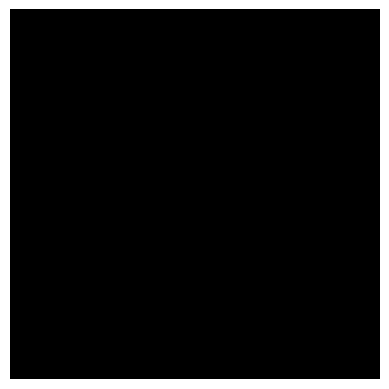

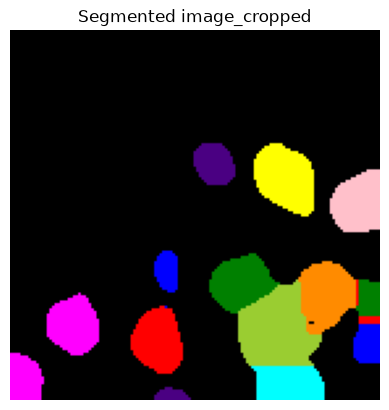

Number of nuclei: 59


<Labels layer 'Watershed segmentation_cropped' at 0x368a22710>

In [26]:
#crop image
im_cropped = ski.io.imread("../Data/Sample3Dimages/crop-DapiB-embryo.tif")

spacing = np.array([1, 0.3946, 0.3946]) #Z, Y, X in µm 

plt.imshow(im_cropped[50], cmap="gray")
plt.show()  

viewer = napari.Viewer()  # create a new viewer
viewer.add_image(im_cropped, name="cropped image", scale=spacing) 

smooth_cropped = ndi.gaussian_filter(im_cropped, sigma= 1/spacing)

threshold_cropped = ski.filters.threshold_otsu(smooth_cropped)
print("Threshold_cropped :", threshold_cropped)

binary_cropped = smooth_cropped > threshold_cropped
plt.imshow(binary_cropped[50], cmap="gray")
plt.title("Binary mask_cropped")
plt.axis("off")
plt.show()  

#Remove objects touching the border of the image
#clearn_bordernuclei = ski.segmentation.clear_border(binary_cropped)

# Remove small objects smaller than 150 pixels
cleaned_nuclei_cropped = ski.morphology.remove_small_objects(binary_cropped, min_size=150)
plt.imshow((cleaned_nuclei_cropped[50]),cmap='gray')
plt.title("Cleaned Binary mask_cropped")
plt.axis(False)
plt.show()


# Label the binary mask
labels_first_cropped = ski.measure.label(cleaned_nuclei_cropped, connectivity=3)
plt.imshow(label2rgb(labels_first_cropped[50]))
np.unique(labels_first_cropped) #Return the sorted unique elements of an array.


plt.axis(False)
plt.title("Labeled binary mask_cropped")
plt.show()
viewer.add_labels(labels_first_cropped, name="Labeled binary mask_cropped", scale=spacing)

#distance transform
distance_cropped = ndi.distance_transform_edt(cleaned_nuclei_cropped, sampling=spacing) #The distance transform computes the distance from each pixel to the nearest background pixel (False in the binary mask).
distance_cropped = ndi.gaussian_filter(distance_cropped , sigma= 1/spacing) #sigma in physical unit, convert to voxel unit by dividing with spacing

plt.imshow(distance_cropped[50])
plt.title("Distance transform_cropped")
plt.show()
viewer.add_image(distance_cropped, name="Distance transform_cropped", scale=spacing)

local_maxi_cropped = ski.morphology.local_maxima(distance_cropped)
print(local_maxi_cropped)

markers_cropped= ndi.label(local_maxi_cropped) [0] # [0] = labeled marker image
print(markers_cropped)
viewer.add_labels(markers_cropped, name="Markers detection_cropped", scale=spacing)

#apply watershed
labels_second_cropped = ski.segmentation.watershed(-distance_cropped,markers= markers_cropped, mask=cleaned_nuclei_cropped)
plt.imshow(label2rgb(markers_cropped[50])) 
plt.axis("off")
plt.show()

plt.imshow(label2rgb(labels_second_cropped[50]))
plt.title("Segmented image_cropped")
plt.axis(False)
plt.show()

print("Number of nuclei:", labels_second_cropped.max())
#props = ski.measure.regionprops(labels_second_cropped) 
#props #properties of each segmented object, such as area, perimeter, centroid, etc.

viewer.add_labels(labels_second_cropped, name="Watershed segmentation_cropped", scale=spacing)    


Unique values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55]
Number of manual nuclei: 55


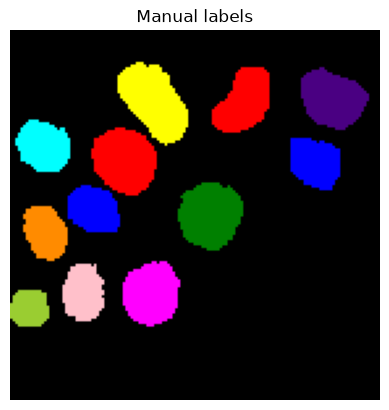

<Image layer 'Manual labels' at 0x356571dd0>

In [27]:
# inspect the manual labels
manual_labels = ski.io.imread ("../Data/Sample3Dimages/crop-DapiB-embryo-labels.tif")
#viewer.add_labels(manual_labels, name="manual labels", scale=spacing) 

# each connected nucleus gets its own unique integer
manual = ski.measure.label(manual_labels, connectivity=3)
print("Unique values:", np.unique(manual))    
print("Number of manual nuclei:", manual.max())

plt.imshow(label2rgb(manual[14], bg_label=0))
plt.title("Manual labels")
plt.axis("off")
plt.show()

viewer.add_image(manual_labels, name="Manual labels")

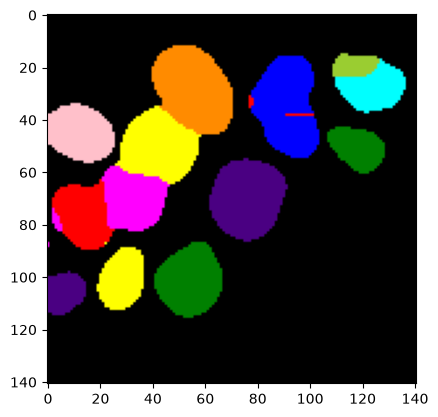

In [28]:
plt.imshow(label2rgb(labels_second_cropped[14], bg_label=0))

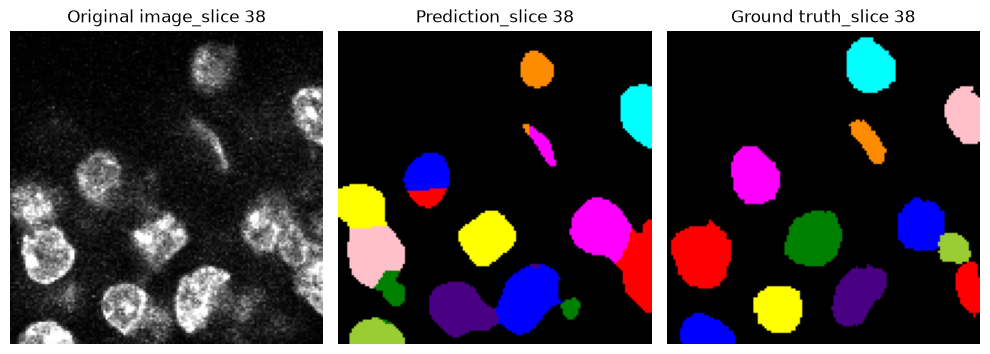

In [29]:
#where is my python vs manual image?
predict = labels_second_cropped
actual = manual_labels


fig, axes = plt.subplots(1, 3, figsize=(10, 5))

axes[0].imshow(im_cropped[38], cmap="gray")
axes[0].set_title("Original image_slice 38")
axes[0].axis("off")

axes[1].imshow(ski.color.label2rgb(predict[38], bg_label=0))
axes[1].set_title("Prediction_slice 38")
axes[1].axis("off")

axes[2].imshow(ski.color.label2rgb(actual[38], bg_label=0))
axes[2].set_title("Ground truth_slice 38")
axes[2].axis("off")

plt.tight_layout()
#plt.suptitle("Segmentation comparison")
plt.savefig("../Results/3D_results.png")
plt.show()


In [30]:
# Calculate true positives (TP), false positives (FP), and false negatives (FN) for each slice, 
# then sum them across all slices to compute overall precision, recall, and F1 score.
tp_total = 0
fp_total = 0
fn_total = 0

for i in range(78):

    testimage = deepcopy(predict[i])
    testimage[testimage > 0] = 1

    groundtruthtest = deepcopy(actual[i])
    groundtruthtest[groundtruthtest > 0] = 1

    tp = np.count_nonzero(testimage * groundtruthtest)
    fp = np.count_nonzero((testimage == 1) & (groundtruthtest == 0))
    fn = np.count_nonzero((testimage == 0) & (groundtruthtest == 1))

    tp_total += tp
    fp_total += fp
    fn_total += fn

precision = tp_total / (tp_total + fp_total)
recall = tp_total / (tp_total + fn_total)
f1 = 2 * precision * recall / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 0.6857395614814372
Recall: 0.912554951195887
F1: 0.7830534699296913
